# This document is dedicated to the data cleaning process, with visualizations of different features etc


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
df_training = pd.read_csv("claims_train.csv")


[Text(0.5, 1.0, 'Distribution of Exposure Values')]

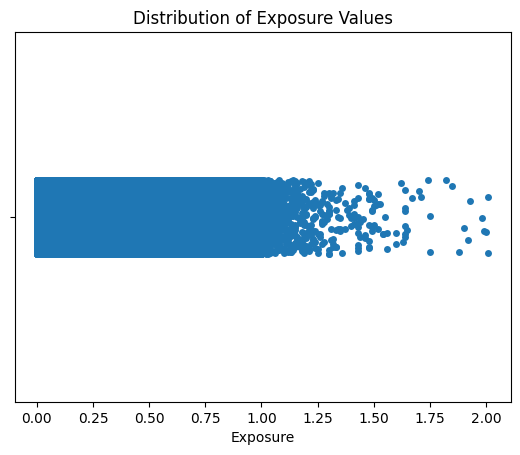

In [4]:
sns.stripplot(data=df_training, x=df_training["Exposure"]).set(title="Distribution of Exposure Values")

[Text(0.5, 1.0, 'Distribution of Exposure Values')]

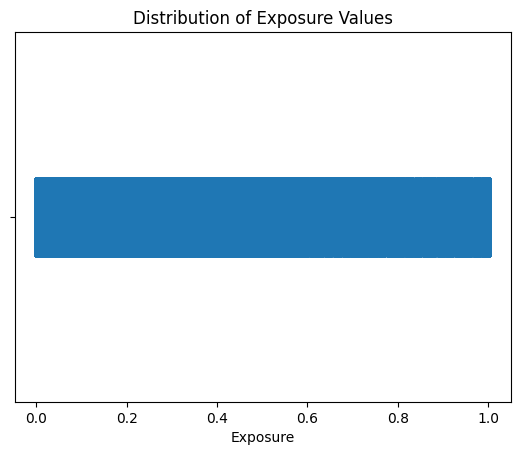

In [5]:
# Removal of exposure >= 1 in order to match the project proposal constraints
exposureMask = df_training["Exposure"] <= 1
df_training = df_training[exposureMask]
df_training.to_csv("claims_train_final.csv", index=False)
sns.stripplot(data=df_training, x=df_training["Exposure"]).set(title="Distribution of Exposure Values")

In [6]:
# Removal of the IDpol category -> From here on out I will be accessing claims_train_final.csv in order to make changes to that file specifically
df_training = pd.read_csv("claims_train_final.csv")
df_training = df_training.drop(columns=["IDpol"], axis=1)
df_training.to_csv("claims_train_final.csv", index=False)

Next up we will be looking at the distributions of different variables, both for categorical and continuous variables

In [7]:
df_training



,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,0,0.43,D,7,18,36,95,B1,Regular,1054,R24
1,0,0.10,D,7,17,80,95,B2,Regular,598,R25
2,0,0.33,E,7,3,36,76,B6,Regular,4172,R82
3,0,0.56,A,5,4,73,52,B13,Diesel,15,R24
4,0,0.27,E,8,0,37,50,B11,Diesel,3021,R53
...,...,...,...,...,...,...,...,...,...,...,...
541411,0,0.20,D,6,10,32,76,B2,Diesel,1314,R24
541412,0,0.06,D,10,14,34,60,B5,Diesel,685,R72
541413,0,0.34,C,6,8,32,95,B5,Diesel,242,R82
541414,0,0.72,E,9,7,39,72,B2,Regular,3301,R73


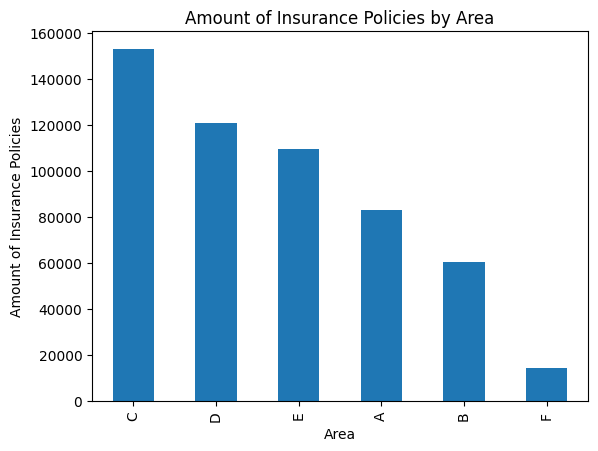

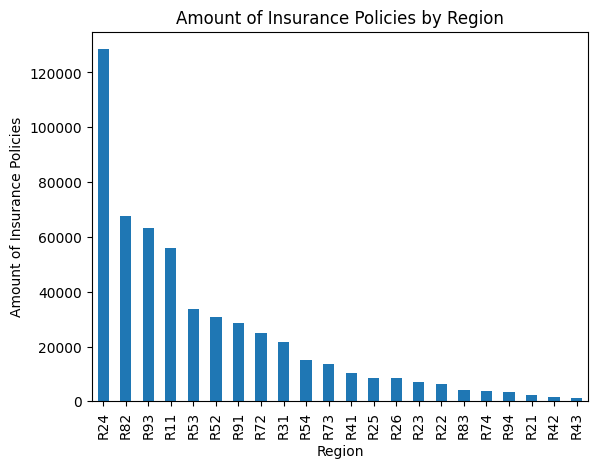

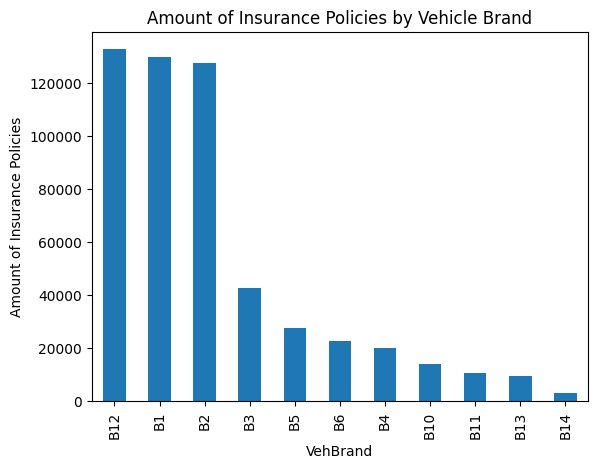

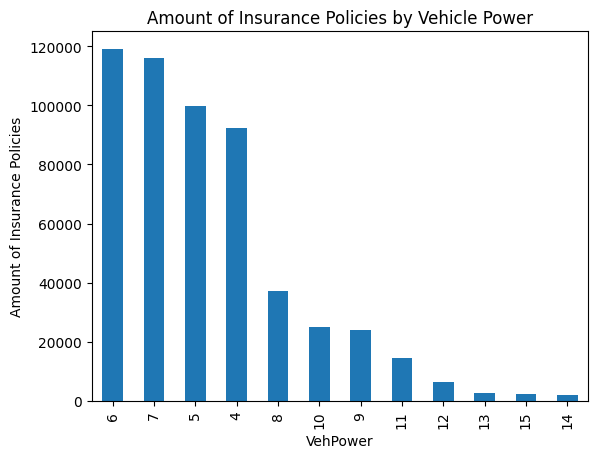

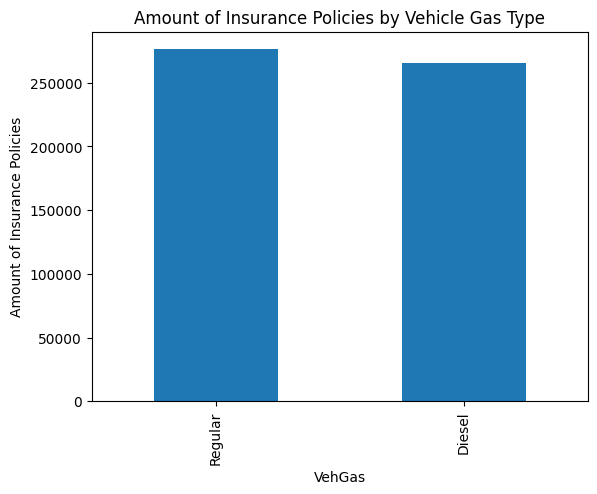

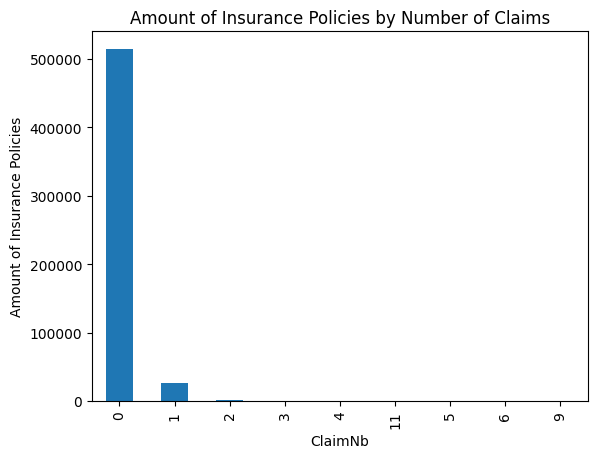

Region
R24    128445
R82     67645
R93     63271
R11     55900
R53     33632
R52     30923
R91     28548
R72     24919
R31     21727
R54     15217
R73     13666
R41     10373
R25      8689
R26      8341
R23      7030
R22      6388
R83      4236
R74      3671
R94      3593
R21      2396
R42      1747
R43      1059
Name: count, dtype: int64

In [50]:
# Plotting various barcharts over categorical variables
df_training["Area"].value_counts().plot(kind="bar")
plt.title("Amount of Insurance Policies by Area")
plt.ylabel("Amount of Insurance Policies")
plt.show()
df_training["Region"].value_counts().plot(kind="bar")
plt.title("Amount of Insurance Policies by Region")
plt.ylabel("Amount of Insurance Policies")
plt.show()
df_training["VehBrand"].value_counts().plot(kind="bar")
plt.title("Amount of Insurance Policies by Vehicle Brand")
plt.ylabel("Amount of Insurance Policies")
plt.show()
df_training["VehPower"].value_counts().plot(kind="bar")
#Since the vehicle power is kind of arbitrary in the dataset it makes sense to treat categorically, especially since there are only like 12 values that it can take
plt.title("Amount of Insurance Policies by Vehicle Power")
plt.ylabel("Amount of Insurance Policies")
plt.show()
df_training["VehGas"].value_counts().plot(kind="bar")
plt.title("Amount of Insurance Policies by Vehicle Gas Type")
plt.ylabel("Amount of Insurance Policies")
plt.show()
# Similarly we can treat claims the same way due to low amount of different values, so it doesnt make sense to do ranges:
df_training["ClaimNb"].value_counts().plot(kind="bar")
plt.title("Amount of Insurance Policies by Number of Claims")
plt.ylabel("Amount of Insurance Policies")
plt.show()
df_training["Region"].value_counts()



Region
R24    128445
R82     67645
R93     63271
R11     55900
R53     33632
R52     30923
R91     28548
R72     24919
R31     21727
R54     15217
R73     13666
R41     10373
R25      8689
R26      8341
R23      7030
R22      6388
R83      4236
R74      3671
R94      3593
R21      2396
R42      1747
R43      1059
Name: count, dtype: int64

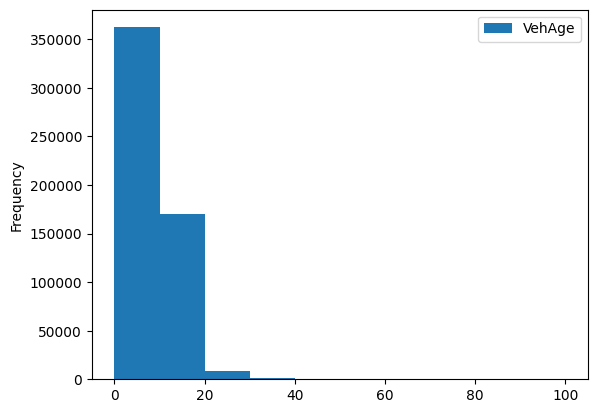

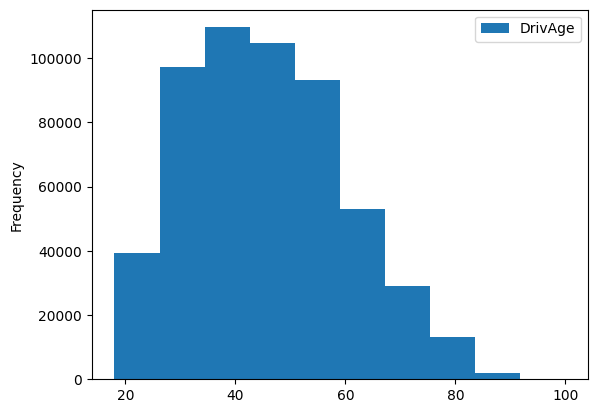

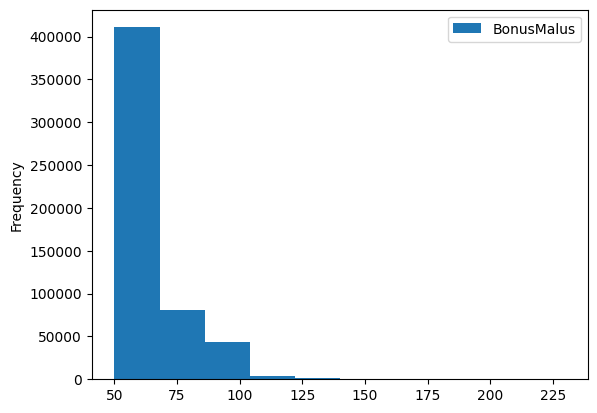

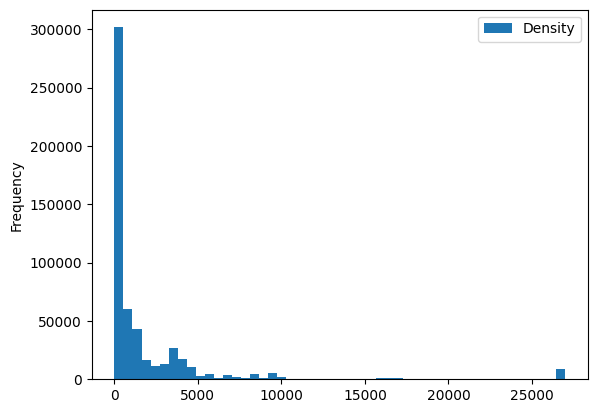

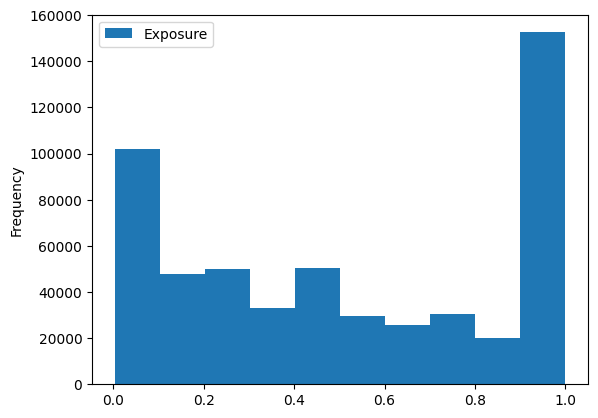

In [ ]:
# Plotting histograms over the continuous variables
df_training.plot.hist(column=["VehAge"], bins=10)

df_training["VehAge"].describe()

# Might want to cap vehicle age at 40 due to very little past that number ^

df_training.plot.hist(column=["DrivAge"], bins=10)
df_training["DrivAge"].value_counts()
# Might want to do something similar with driverage, capping at 95 or 90 ^

mask = df_training["BonusMalus"] > 150
df_training.plot.hist(column=["BonusMalus"], bins=10)

#Also with BonusMalus we dont really have any values above 150 ^ might make sense to clamp it at ~150 where all values above go to 150
df_training.plot.hist(column=["Density"], bins=50)

# Seems like most people live in low density areas ^
df_training.plot.hist(column=["Exposure"], bins=10)

df_training["Region"].value_counts()

[Text(0.5, 0, 'Vehicle Age'),
 Text(0.5, 1.0, 'Number of Insurance Policies by Vehicle Age')]

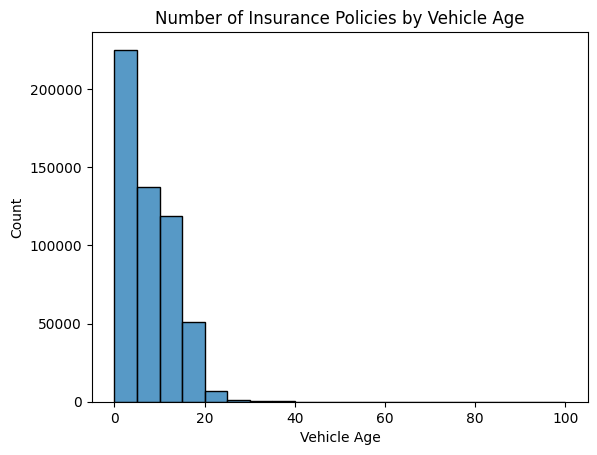

In [27]:
sns.histplot(data=df_training, x=df_training["VehAge"], bins=20).set(xlabel="Vehicle Age", title="Number of Insurance Policies by Vehicle Age")


[Text(0.5, 0, 'Vehicle Age'),
 Text(0.5, 1.0, 'Number of Insurance Policies by Vehicle Age')]

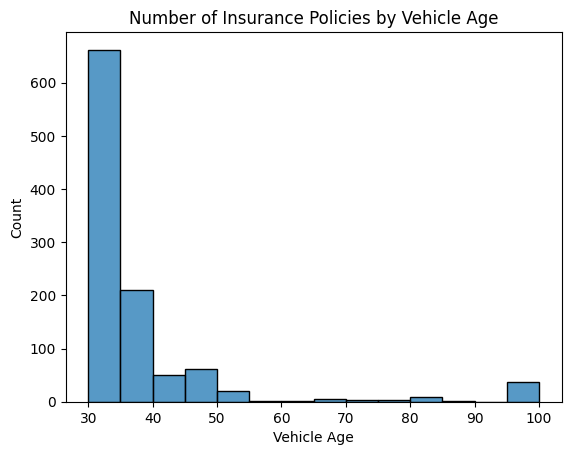

In [25]:
mask = df_training["VehAge"] >= 30
df_maskedtraining = df_training[mask].copy()
sns.histplot(data=df_maskedtraining, x=df_maskedtraining["VehAge"], bins=14).set(xlabel="Vehicle Age", title="Number of Insurance Policies by Vehicle Age")

[Text(0.5, 0, 'Driver Age'),
 Text(0.5, 1.0, 'Number of Insurance Policies by Driver Age')]

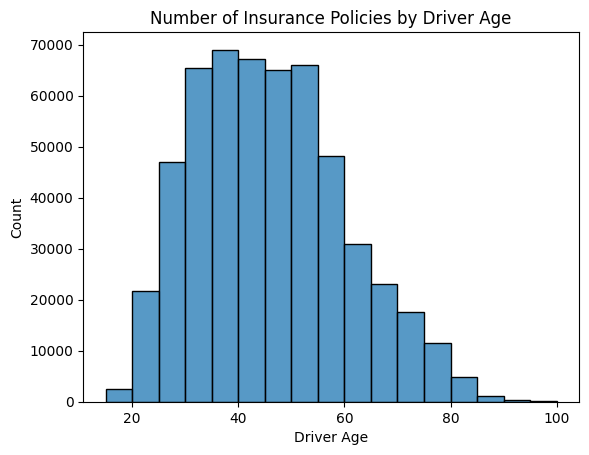

In [31]:
sns.histplot(data=df_training, x=df_training["DrivAge"], binwidth=5, binrange=(15, 100)).set(xlabel="Driver Age", title="Number of Insurance Policies by Driver Age")


[Text(0.5, 0, 'Driver Age'),
 Text(0.5, 1.0, 'Number of Insurance Policies by Driver Age')]

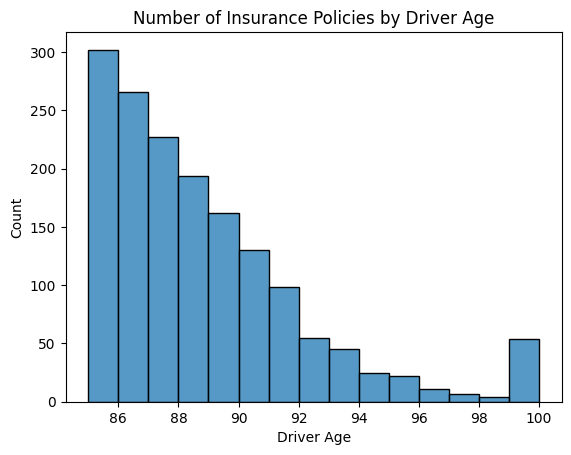

In [40]:
mask = df_training["DrivAge"] >= 85
df_maskedtraining = df_training[mask].copy()
sns.histplot(data=df_maskedtraining, x=df_maskedtraining["DrivAge"], bins=15).set(xlabel="Driver Age", title="Number of Insurance Policies by Driver Age")

[Text(0.5, 0, 'Bonus-malus'),
 Text(0.5, 1.0, 'Number of Insurance Policies by Bonus-malus value')]

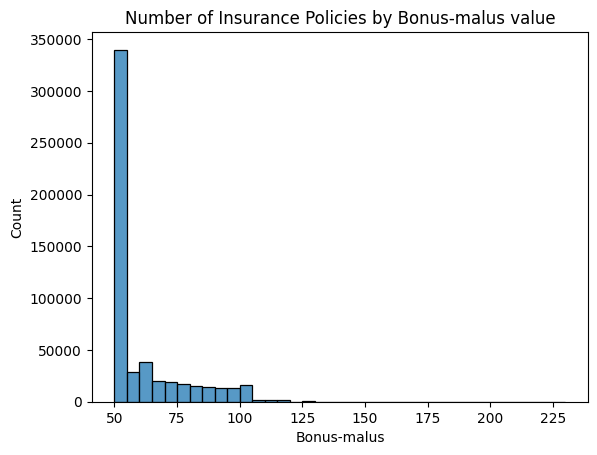

In [48]:
sns.histplot(data=df_training, x=df_training["BonusMalus"], binwidth=5, binrange=(50, max(df_training["BonusMalus"]))).set(xlabel="Bonus-malus", title="Number of Insurance Policies by Bonus-malus value")

230

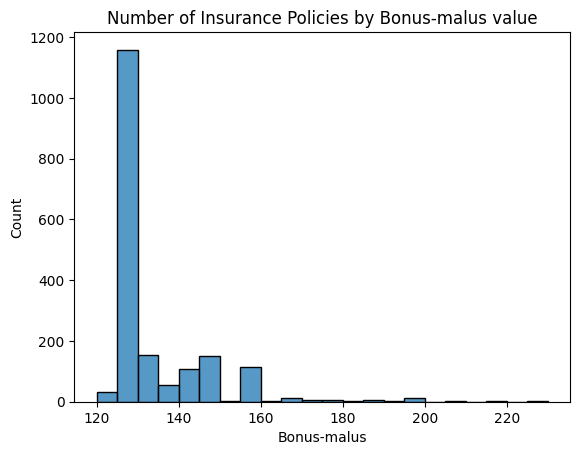

In [49]:
sns.histplot(data=df_training, x=df_training["BonusMalus"], binwidth=5, binrange=(120, max(df_training["BonusMalus"]))).set(xlabel="Bonus-malus", title="Number of Insurance Policies by Bonus-malus value")
max(df_training["BonusMalus"])

Now we will take a look at a scatter matrix plot over all features, to try to see if any of the variables are highly correlated, it will make sense to remove features with high correlation 

array([[<Axes: xlabel='Exposure', ylabel='Exposure'>,
        <Axes: xlabel='VehAge', ylabel='Exposure'>,
        <Axes: xlabel='DrivAge', ylabel='Exposure'>,
        <Axes: xlabel='BonusMalus', ylabel='Exposure'>,
        <Axes: xlabel='Density', ylabel='Exposure'>],
       [<Axes: xlabel='Exposure', ylabel='VehAge'>,
        <Axes: xlabel='VehAge', ylabel='VehAge'>,
        <Axes: xlabel='DrivAge', ylabel='VehAge'>,
        <Axes: xlabel='BonusMalus', ylabel='VehAge'>,
        <Axes: xlabel='Density', ylabel='VehAge'>],
       [<Axes: xlabel='Exposure', ylabel='DrivAge'>,
        <Axes: xlabel='VehAge', ylabel='DrivAge'>,
        <Axes: xlabel='DrivAge', ylabel='DrivAge'>,
        <Axes: xlabel='BonusMalus', ylabel='DrivAge'>,
        <Axes: xlabel='Density', ylabel='DrivAge'>],
       [<Axes: xlabel='Exposure', ylabel='BonusMalus'>,
        <Axes: xlabel='VehAge', ylabel='BonusMalus'>,
        <Axes: xlabel='DrivAge', ylabel='BonusMalus'>,
        <Axes: xlabel='BonusMalus', ylabel=

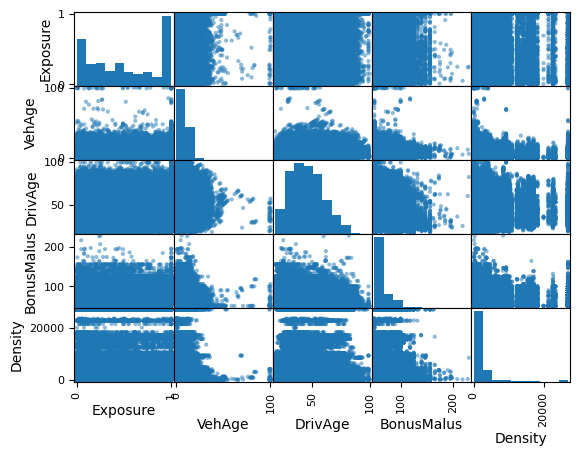

In [ ]:
#df_training_continuous = df_training.copy()
#df_training_continuous = df_training_continuous.drop(columns=["ClaimNb", "VehPower", "Area", "Region", "VehBrand", "VehGas"])
#df_training_continuous
#pd.plotting.scatter_matrix(df_training_continuous)

<Axes: xlabel='Density', ylabel='Area'>

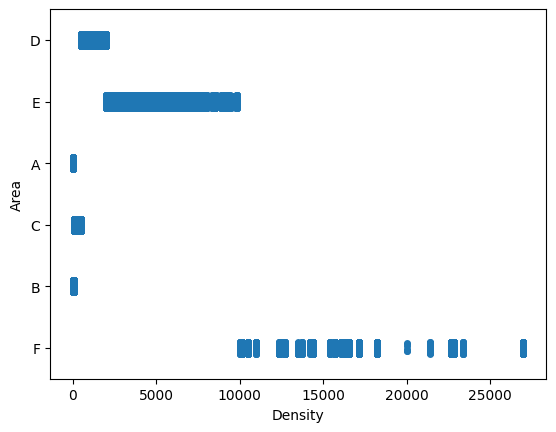

In [ ]:
xtest = df_training["Area"]
ytest = df_training["Density"]
df_training2 = df_training.copy()
xtest = df_training["Area"]
ytest = df_training["Density"]
sns.stripplot(data=df_training, x=ytest, y=xtest)


<Axes: xlabel='Density', ylabel='Area'>

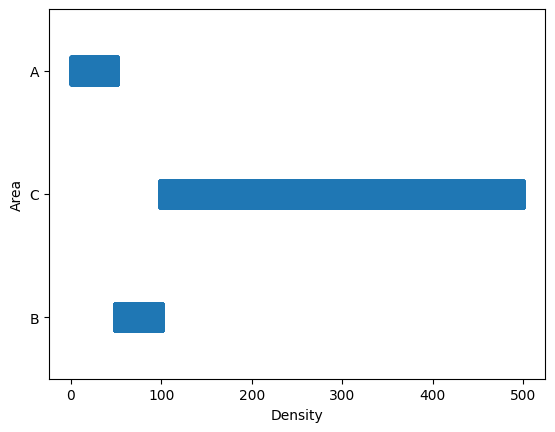

In [19]:
mask = df_training2["Density"] < 500
df_training2 = df_training2[mask]
xtest = df_training2["Area"]
ytest = df_training2["Density"]
sns.stripplot(data=df_training2, x=ytest, y=xtest)

In [ ]:
a = df_training["ClaimNb"]
print(len(a))
df_training["ClaimNb"].value_counts()

541416


ClaimNb
0     514246
1      25679
2       1414
3         67
4          4
11         2
5          2
6          1
9          1
Name: count, dtype: int64